# 06 Gbm Analysis

Notebook canónico. Los datos se leen de `datasets/` y los productos derivados se guardan en `results/`.


In [1]:
# Canonical notebook setup
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.paths import DATASETS_DIR, analysis_output_dirs

ANALYSIS = '06_gbm_analysis'
OUTPUTS = analysis_output_dirs(ANALYSIS)
# Guardar figuras nuevas en OUTPUTS['figures'] y tablas en OUTPUTS['tables'].


# GBM analysis

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

## Read data

In [3]:
PATH_MODULES = DATASETS_DIR / 'module-prediction-KO-and-COG'

In [4]:
samples_modules = dict()

In [5]:
for file_ in PATH_MODULES.iterdir():
    if 'modules' in file_.name:
        data = pd.read_csv(file_, sep = '\t')
        data = data[data['Coverage'] > 0.35]
        samples_modules[file_.stem] = data
        # samples_modules[file_.split('.')[0]] = pd.read_csv(PATH_MODULES + file_, sep = '\t')

## Presence graph

In [6]:
gbm_metadata = pd.read_excel(DATASETS_DIR / '41564_2018_337_MOESM4_ESM.xlsx', sheet_name='Supplementary Table 10', skiprows = 1)

C:\Users\rafap\anaconda3\envs\clustering-env\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


In [7]:
gbm_count = dict()

In [8]:
for gbm in list(gbm_metadata['Module.number']):
    gbm_count[gbm] = 0

In [9]:
for sample in samples_modules:
    for gbm in set(samples_modules[sample]['Module']):
        gbm_count[gbm] += 1

In [10]:
df = pd.DataFrame(list(gbm_count.items()), columns=['GBM', 'Count'])

In [11]:
df['Count'] = df['Count'] / len(samples_modules)

In [12]:
gbm_metadata.head()

,Module.number,Description,Label in Figure 3,Function,Structure,Pathway,Depression association reported,Depression association reference,Name_DB,Code,BBB.Prediction,BBB.Probability,Int.Prediction,Int.Probability,Unnamed: 14
0,MGB049,Tryptophan degradation,Trp deg,Amino acid,Amino acid,Tryptophan-derived,1,"PMID:2521647,11888576,11022402,26805875",L-Tryptophan,DB00150,+,0.9510,+,0.9840,* Predictions for each compound to cross the b...
1,MGB050,Glutamate degradation I,Glu deg I,Amino acid/ Neurotransmitter,Amino acid,Glutamate-derived,1,"PMID: 22731961,11986998,21827775",L-Glutamic Acid,DB00142,NaN,NaN,NaN,NaN,NaN
2,MGB051,Glutamate degradation II,Glu deg II,Amino acid/ Neurotransmitter,Amino acid,Glutamate-derived,1,"PMID: 22731961,11986998,21827775",L-Glutamic Acid,DB00142,NaN,NaN,NaN,NaN,NaN
3,MGB052,Butyrate synthesis I,Butyrate synt I,SCFA,SCFA,Butyrate,0,NaN,Isobutyric Acid,DB02531,+,0.9624,+,0.9848,NaN
4,MGB053,Butyrate synthesis II,Butyrate synt II,SCFA,SCFA,Butyrate,0,NaN,Isobutyric Acid,DB02531,+,0.9624,+,0.9848,NaN


In [13]:
gbm_metadata[gbm_metadata['Label in Figure 3'] == 'ClpB']

,Module.number,Description,Label in Figure 3,Function,Structure,Pathway,Depression association reported,Depression association reference,Name_DB,Code,BBB.Prediction,BBB.Probability,Int.Prediction,Int.Probability,Unnamed: 14
36,MGB029,ClpB (ATP-dependent chaperone protein),ClpB,Chaperone,Protein,ClpB,0,NaN,ClpB,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
labels = []
for gbm in list(df['GBM']):
    labels.append(gbm_metadata[gbm_metadata['Module.number'] == gbm]['Label in Figure 3'].iloc[0])

In [15]:
df['Labels'] = labels

In [16]:
df

,GBM,Count,Labels
0,MGB049,0.478049,Trp deg
1,MGB050,0.000000,Glu deg I
2,MGB051,0.448780,Glu deg II
3,MGB052,0.995122,Butyrate synt I
4,MGB053,0.414634,Butyrate synt II
5,MGB054,0.956098,Propionate synt II
6,MGB055,0.482927,Propionate synt III
7,MGB056,0.200000,Propionate deg I
8,MGB001,0.897561,Serotonin synt I
9,MGB002,0.000000,Serotonin synt II


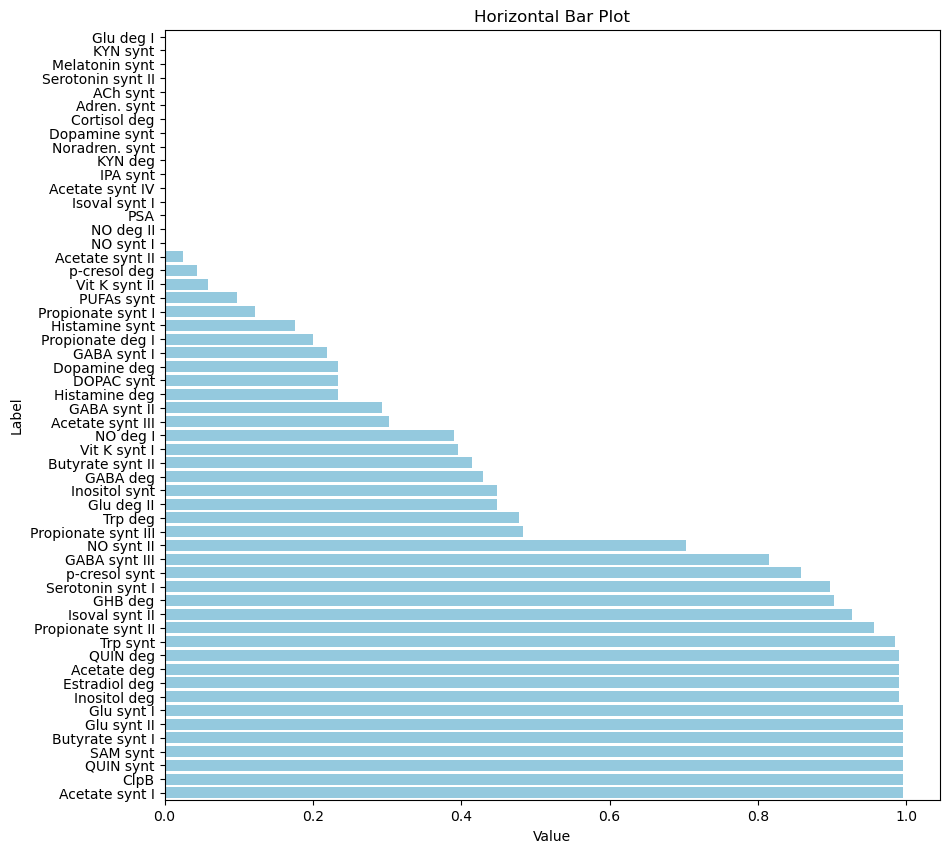

In [17]:
df = df.sort_values(by='Count', ascending=True)
plt.figure(figsize=(10, 10))  # Optional: Adjust the figure size
sns.barplot(data=df, y='Labels', x='Count', orient='h', color="skyblue")

# Add labels and title
plt.xlabel("Value")
plt.ylabel("Label")
plt.title("Horizontal Bar Plot")

# Show the plot
plt.savefig(OUTPUTS['figures'] / 'gbm_kos_from_humann.png', dpi=400)
plt.show()

## Rare GBMs (according to Valles-Colomer)

In [18]:
rare_gbms = [
    "Dopamine synt",
    "ACh synt",
    "Glu deg I",
    "Acetate synt II",
    "NO synt I",
    "Propionate synt III",
    "Butyrate synt II",
    "Serotonin synt II",
    "Histamine synt",
    "NO deg II",
    "KYN synt",
    "p-cresol deg",
    "Propionate synt I",
    "Glu deg II"
]

In [19]:
rare = df[(df['Labels'].isin(rare_gbms)) & (df['Count'] > 0)]

In [20]:
rare

,GBM,Count,Labels
51,MGB044,0.024390,Acetate synt II
23,MGB016,0.043902,p-cresol deg
55,MGB048,0.121951,Propionate synt I
16,MGB009,0.175610,Histamine synt
4,MGB053,0.414634,Butyrate synt II
2,MGB051,0.448780,Glu deg II
6,MGB055,0.482927,Propionate synt III


In [21]:
species_gbm = dict()
for gbm in list(rare['GBM']):
    species_gbm[gbm] = set()
    for sample in samples_modules:
        if gbm in list(samples_modules[sample]['Module']):
            aux = samples_modules[sample][samples_modules[sample]['Module'] == gbm]
            for specie in aux['Taxon']:
                species_gbm[gbm].add(specie)
            
    

In [22]:
species_gbm

{'MGB044': {'Clostridium aldenense',
  'Clostridium citroniae',
  'Dorea longicatena',
  'Hungatella hathewayi'},
 'MGB016': {'Asaccharobacter celatus',
  'Klebsiella pneumoniae',
  'Pseudocitrobacter faecalis',
  'Raoultella ornithinolytica'},
 'MGB048': {'Enterobacter cloacae',
  'Escherichia coli',
  'Klebsiella aerogenes',
  'Klebsiella oxytoca',
  'Klebsiella pneumoniae',
  'Klebsiella quasipneumoniae',
  'Klebsiella variicola'},
 'MGB009': {'Cetobacterium somerae',
  'Clostridium baratii',
  'Clostridium perfringens',
  'Eggerthella lenta',
  'Gordonibacter pamelaeae',
  'Gordonibacter urolithinfaciens',
  'Paeniclostridium sordellii',
  'Streptococcus thermophilus'},
 'MGB053': {'Eubacterium ramulus'},
 'MGB051': {'Cetobacterium somerae',
  'Citrobacter freundii',
  'Citrobacter youngae',
  'Clostridium sp CAG 138',
  'Clostridium sp CAG 169',
  'Clostridium sp CAG 242',
  'Escherichia coli',
  'Eubacterium infirmum',
  'Eubacterium sulci',
  'Firmicutes bacterium AM10 47',
  'F

In [23]:
metadata = pd.read_excel(DATASETS_DIR / 'metadata_LATINBIOTA_MEXICO.xlsx', sheet_name='Data')

rural_ids = list(metadata[metadata['Lifestyle'] == 'Rural']['Lane'])
urban_ids = list(metadata[metadata['Lifestyle'] == 'Urban']['Lane'])

In [24]:
present_gbms = list(df[df['Count'] > 0]['GBM'])

df2 = dict()
for sample in samples_modules:
    aux = []
    for gbm in present_gbms:
        if gbm in list(samples_modules[sample]['Module']):
            aux.append(1)
        else:
            aux.append(0)
    df2[sample] = aux


df3 = pd.DataFrame(df2,  index = present_gbms)

rural_gbms = df3[[x for x in rural_ids if x in df3.columns]]
urban_gbms = df3[[x for x in urban_ids if x in df3.columns]]

for gbm in df3.T.columns:
    print(gbm)
    r = sum(list(rural_gbms.T[gbm]))
    u = sum(list(urban_gbms.T[gbm]))
    print(r, u)

MGB044
0 5
MGB016
5 4
MGB041
0 12
MGB042
2 18
MGB048
19 6
MGB009
20 16
MGB056
27 14
MGB020
30 15
MGB023
34 14
MGB024
34 14
MGB010
34 14
MGB021
42 18
MGB045
32 30
MGB027
59 21
MGB040
59 22
MGB053
25 60
MGB019
60 28
MGB037
15 77
MGB051
46 46
MGB049
34 64
MGB055
32 67
MGB026
66 78
MGB022
90 77
MGB015
97 79
MGB001
104 80
MGB039
103 82
MGB035
106 84
MGB054
117 79
MGB005
118 84
MGB033
119 84
MGB047
118 85
MGB031
119 84
MGB038
118 85
MGB006
119 85
MGB007
119 85
MGB052
119 85
MGB036
119 85
MGB032
119 85
MGB029
119 85
MGB043
119 85


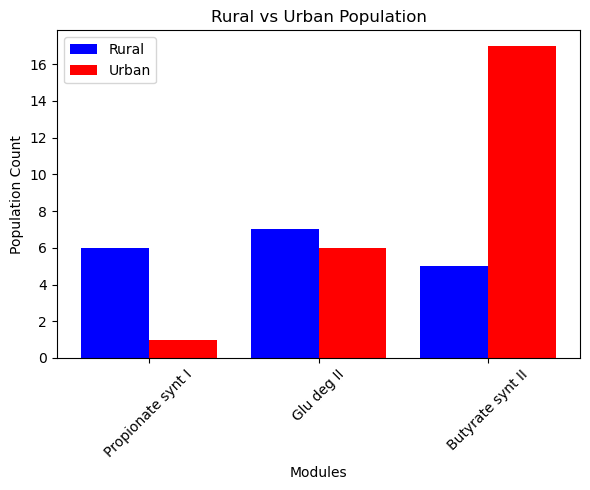

In [25]:
import numpy as np

# Updated Data with Labels
labels = ["Propionate synt I", "Glu deg II", "Butyrate synt II"]
rural = [6, 7, 5]
urban = [1, 6, 17]

x = np.arange(len(labels))  # Label positions
width = 0.4  # Bar width

# Create the figure and axis
fig, ax = plt.subplots(figsize=(6, 5))

# Plot bars
ax.bar(x - width/2, rural, width, label="Rural", color="blue")
ax.bar(x + width/2, urban, width, label="Urban", color="red")

# Labels and formatting
ax.set_xlabel("Modules")
ax.set_ylabel("Population Count")
ax.set_title("Rural vs Urban Population")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)  # Rotated for better visibility
ax.legend()

# Show plot
plt.tight_layout()
plt.show()
